## Forward looking sonar image preprocessing

Patches to graph are extracting from fls image based on strong textures.

Because fls images are strongly noised, preprocessing are necessery. 

In [3]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

# import matplotlib
import matplotlib.pyplot as plt

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.encoders import Encoder
from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects


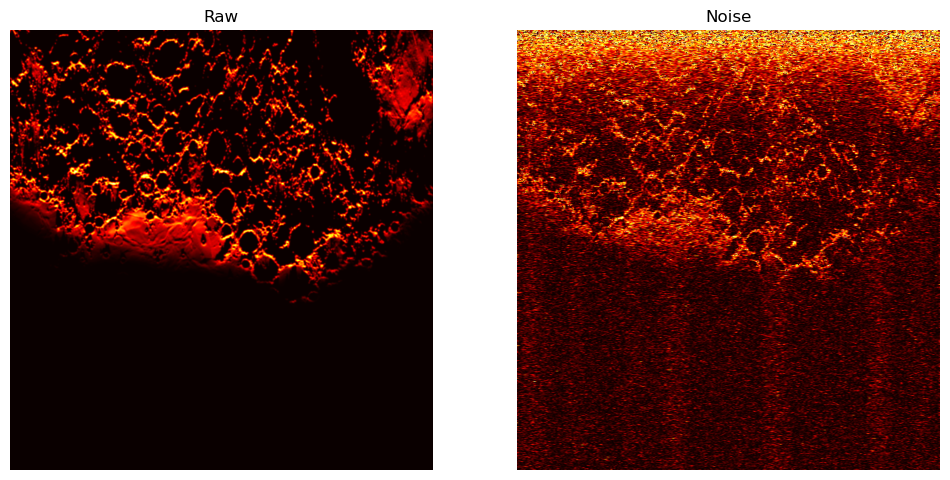

In [4]:
data_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'
new_frame = cv2.imread(data_pth, 0)

noise_frame = new_frame.copy()
noise_frame = addBandReflects(noise_frame, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
noise_frame = energyLoss(noise_frame, alpha = 0.02)
noise_frame = addSpeckleNoise(noise_frame, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
noise_frame = noise_frame.astype(np.uint8)

plt.figure(figsize=(12, 10))
# plt.imshow(noise_frame, cmap = 'hot')
# plt.axis('off')

plt.subplot(1, 2, 1)
plt.title("Raw")
plt.imshow(new_frame, cmap='hot')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noise")
plt.imshow(noise_frame, cmap='hot')
plt.axis('off')

plt.show()


## Gradient base method
Gradient for searching structures on image

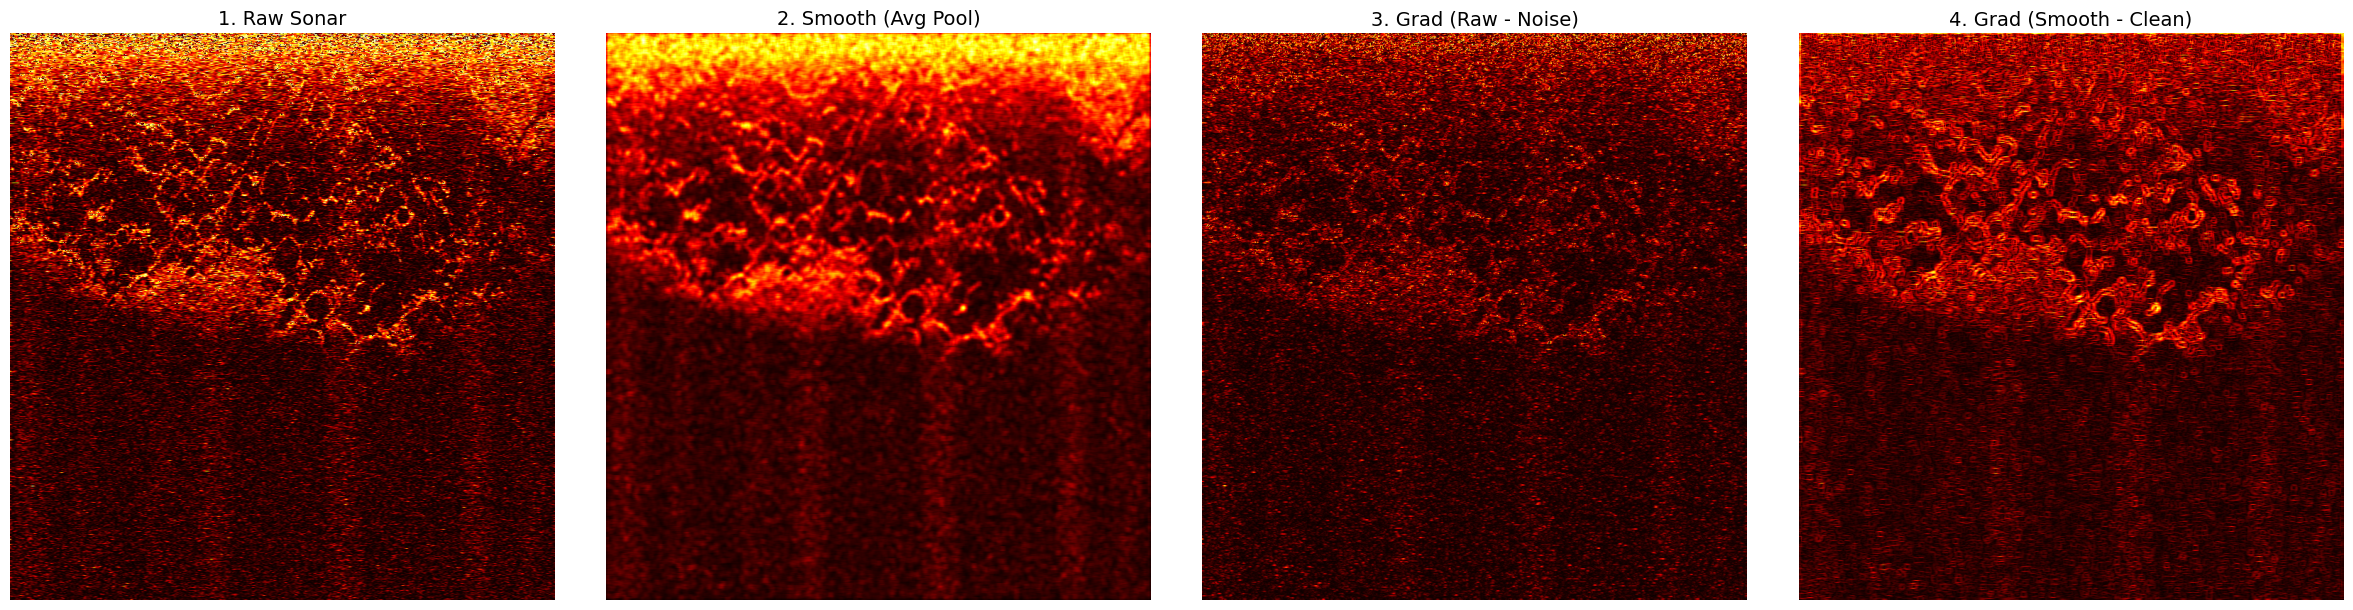

In [5]:
noise_tensor = torch.from_numpy(noise_frame).float().unsqueeze(0).unsqueeze(0)

def get_gradient(img):
    px = F.pad(img, (0, 1, 0, 0), mode='reflect')
    dx = px[..., :, 1:] - px[..., :, :-1]
    
    py = F.pad(img, (0, 0, 0, 1), mode='reflect')
    dy = py[..., 1:, :] - py[..., :-1, :]
    
    return torch.sqrt(dx**2 + dy**2)

g_raw = get_gradient(noise_tensor)

smooth_tensor = F.avg_pool2d(noise_tensor, kernel_size=7, stride=1, padding=3)
g_smooth = get_gradient(smooth_tensor)

def normalize_for_plot(tensor):
    t = tensor.detach().squeeze().cpu().numpy()
    t_min, t_max = t.min(), t.max()
    return (t - t_min) / (t_max - t_min + 1e-8)

plt.figure(figsize=(24, 6)) 

data = [
    (noise_frame, "1. Raw Sonar"),
    (normalize_for_plot(smooth_tensor), "2. Smooth (Avg Pool)"),
    (normalize_for_plot(g_raw), "3. Grad (Raw - Noise)"),
    (normalize_for_plot(g_smooth), "4. Grad (Smooth - Clean)")
]

for i, (img, title) in enumerate(data):
    plt.subplot(1, 4, i + 1)
    plt.title(title, fontsize=14)
    plt.imshow(img, cmap='hot')
    plt.axis('off')

plt.tight_layout()
plt.show()

**Lee filter/ Frost filter**
- calculate local variance (eg. in window 7x7)
- when there is no texture, variance comes only from noise - const value
- whene there are textures, variance grows immidietly 

**Harris response**

In [6]:
def lee_filter(frame, ksize=7, pad=3, noise_mul=5.0):
    # 1. E(x) - local mean
    mean = F.avg_pool2d(frame, ksize, stride=1, padding=pad)
    
    # 2. E(x^2) - local square mean
    mean_sq = F.avg_pool2d(frame**2, ksize, stride=1, padding=pad)
    
    # 3. Var(x) = E(x^2) - [E(x)]^2 
    var = mean_sq - mean**2
    var = torch.clamp(var, min=0) # Numerical error protection
    
    # 4. Apriximate noise var
    noise_var = torch.mean(var) * noise_mul
    
    # 5. gain k = Var(x) / (Var(x) + noise_var)
    k = var / (var + noise_var + 1e-8)
    
    # 6. Output filtered image: mean + k * (frame - mean)
    return mean + k * (frame - mean)

In [7]:
def harris_response(frame, ksize=7, padding = 3):
    
    # Gradients x and y
    dx = F.pad(frame[...,:,1:] - frame[...,:,:-1], (0,1,0,0))
    dy = F.pad(frame[...,1:,:] - frame[...,:-1,:], (0,0,0,1))
    
    # Structural matrix components
    Ixx = F.avg_pool2d(dx**2, ksize, stride=1, padding=padding)
    Iyy = F.avg_pool2d(dy**2, ksize, stride=1, padding=padding)
    Ixy = F.avg_pool2d(dx*dy, ksize, stride=1, padding=padding)
    
    # Shi-Tomasi response (min eigenvalue form)
    # determinant = Ixx*Iyy - Ixy**2, trace = Ixx + Iyy
    trace = Ixx + Iyy
    determinant = Ixx * Iyy - Ixy**2
    
    response = determinant / (trace + 1e-8)
    return response

noise tensor shape: torch.Size([1, 1, 800, 768])


(-0.5, 767.5, 799.5, -0.5)

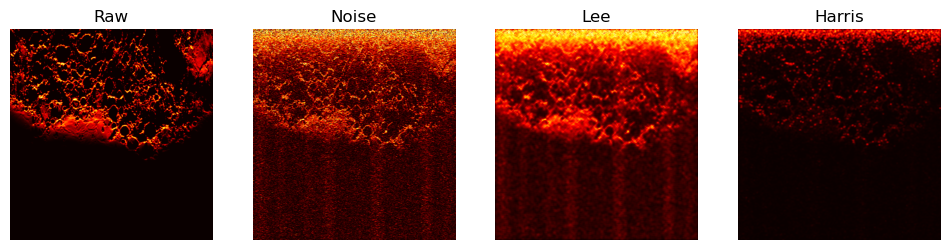

In [8]:
noise_tensor = torch.from_numpy(noise_frame).float().unsqueeze(0).unsqueeze(0)
print(f'noise tensor shape: {noise_tensor.shape}')
lee_tensor = lee_filter(noise_tensor , ksize=11, pad=5, noise_mul = 10.0)
harris_tensor = harris_response(noise_tensor)
plt.figure(figsize=(12, 10))

# Orginal
plt.subplot(1, 4, 1)
plt.title("Raw")
plt.imshow(new_frame, cmap='hot')
plt.axis('off')

# Noise
plt.subplot(1, 4, 2)
plt.title("Noise")
plt.imshow(normalize_for_plot(noise_tensor), cmap='hot')
plt.axis('off')

# Lee filter 
plt.subplot(1, 4, 3)
plt.title("Lee")
plt.imshow(normalize_for_plot(lee_tensor), cmap='hot')
plt.axis('off')

# Harris response
plt.subplot(1, 4, 4)
plt.title("Harris")
plt.imshow(normalize_for_plot(harris_tensor), cmap='hot')
plt.axis('off')